Extracting EDF parameters from /Users/wanghley/Workspace/Projects/ML-driven EEG biomarkers/data/XU/XUAWAKE7.EDF...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 145407  =      0.000 ...   567.996 secs...
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_12905/2307154682.py:38: UserWarning: Infinite value in PSD for channels OSAT, PR.
These channels might be dead.
  raw.compute_psd().plot()


NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
Effective window size : 8.000 (s)


/Users/wanghley/Workspace/Projects/ML-driven EEG biomarkers/.venv/lib/python3.13/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


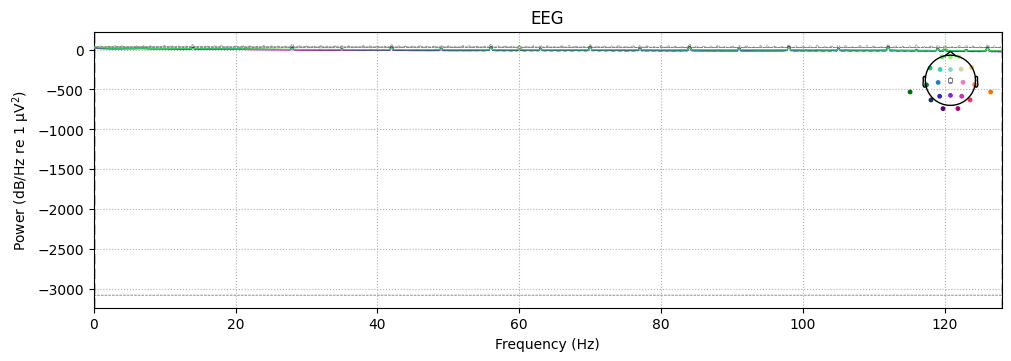

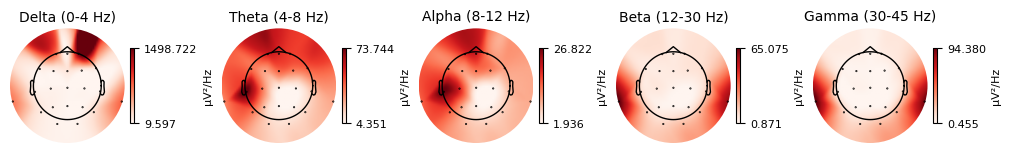

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 845 samples (3.301 s)

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_12905/2307154682.py:46: UserWarning: Infinite value in PSD for channels OSAT, PR.
These channels might be dead.
  raw_filtered.compute_psd().plot()


NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
Effective window size : 8.000 (s)


/Users/wanghley/Workspace/Projects/ML-driven EEG biomarkers/.venv/lib/python3.13/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


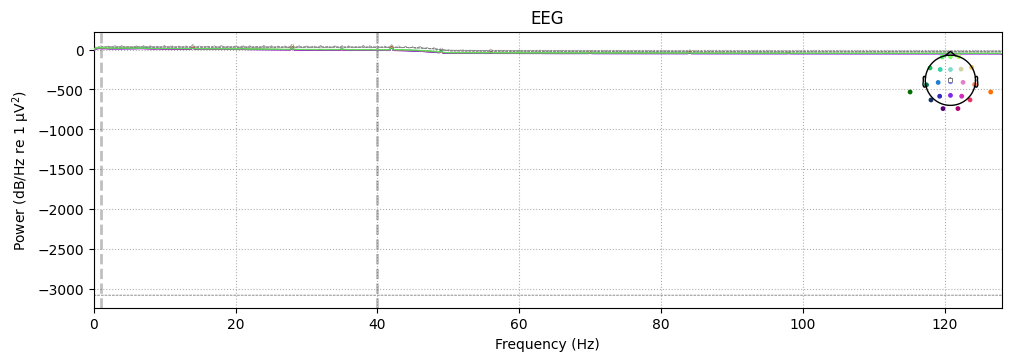

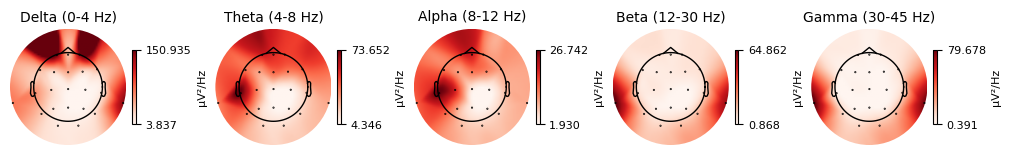

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 5.5s.
Using EOG channels: LOC1, LOC2
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2560 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50

ValueError: No appropriate components found for the given picks ([])

In [5]:
import mne
from mne.preprocessing import ICA

# 1. Load Data
raw = mne.io.read_raw_edf('../data/XU/XUAWAKE7.EDF', preload=True)

# Load standard montage
standard_montage = mne.channels.make_standard_montage('standard_1005')

# Get channel positions as dict
montage_positions = standard_montage.get_positions()['ch_pos']

# Find channels present in both raw data and the standard montage
common_chs = list(set(raw.ch_names) & set(montage_positions.keys()))

# Build subset dict of positions
subset_ch_pos = {ch: montage_positions[ch] for ch in common_chs}

# Create DigMontage using make_dig_montage
subset_montage = mne.channels.make_dig_montage(ch_pos=subset_ch_pos, coord_frame='head')

# Set the partial montage on raw (ignore missing channels)
raw.set_montage(subset_montage, on_missing='ignore')

# Define channels to exclude from topomap plotting (non-EEG or overlapping)
exclude_chs = ['T1', 'T2', 'EKGL', 'EKGR', 'LOC1', 'LOC2',
               'EMG1', 'EMG2', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14',
               'X15', 'X16', 'X17', 'X18', 'DC1', 'DC2', 'DC3', 'DC4',
               'OSAT', 'PR']

# Mark excluded channels as bad (optional but recommended)
raw.info['bads'].extend(exclude_chs)

# Pick only good EEG channels for topomap visualization
eeg_picks = mne.pick_types(raw.info, eeg=True, exclude='bads')

# 2. Initial Visualization
raw.compute_psd().plot()
raw.plot_psd_topomap(picks=eeg_picks)

# 3. (Optional) Mark additional bad channels if known
# raw.info['bads'].append('bad_channel_name')

# 4. Filtering
raw_filtered = raw.copy().filter(l_freq=1.0, h_freq=40.0)
raw_filtered.compute_psd().plot()
raw_filtered.plot_psd_topomap(picks=eeg_picks)

# 5. ICA Fitting for artifact removal
ica = ICA(n_components=15, random_state=97, max_iter='auto')
ica.fit(raw_filtered)

# 6. Identify artifact ICs using LOC1 and LOC2 channels as surrogate EOG
eog_indices, eog_scores = ica.find_bads_eog(raw_filtered, ch_name=['LOC1', 'LOC2'])
ica.exclude = eog_indices

# 7. Plot ICA components and sources related to artifacts
ica.plot_components(picks=eog_indices)
ica.plot_sources(raw_filtered, show_scrollbars=False)

# 8. Apply ICA cleaning to raw (unfiltered)
raw_clean = raw.copy()
ica.apply(raw_clean)

# 9. PSD and topomap after artifact removal
raw_clean.compute_psd().plot()
raw_clean.plot_psd_topomap(picks=eeg_picks)
